# 07 — DRL v2: PPO · M1Y WFO · Long+Short · 1h BTC · Realistic Fees

## v2 fixes vs v1

| Problem (v1) | Root cause | Fix (v2) |
|---|---|---|
| 2,483 trades → fatal fee drag (−86%) | Only L↔S flip penalised; any Flat→Long entry cost just 0.05% taker | **Step penalty 0.20%** on **any** position change (new) |
| Agent still churned 2,400+ times | Churn penalty 0.10% too soft for direct flips | **Churn penalty 0.10% → 0.20%** on direct L↔S |
| Policy converged fast to suboptimal high-frequency regime | Low entropy (0.01) allowed premature commitment; 300k ts may underfit | **ent_coef 0.01 → 0.02** · **timesteps 300k → 500k** |

**Signal sanity (v1):** zero-fee upper bound was **+0.578 Sharpe / +63.9% return** — the directional edge exists.  
v2 targets **<500 trades** (vs 2,483 in v1) by making each position change genuinely costly to PPO in training.

| Design dimension | Choice |
|---|---|
| **Algorithm** | PPO (Stable-Baselines3) |
| **WFO scheme** | M1Y sliding · 8760h train · 720h step · 92 folds |
| **Action space** | Discrete(3): Short / Flat / Long |
| **Step penalty** | 0.20% on ANY position change (new in v2) |
| **Churn penalty** | 0.20% on direct L↔S flip (up from 0.10%) |
| **Taker fee** | 0.05% on entry/exit (unchanged) |
| **Episode length** | 1,000 bars · random start (unchanged from v1) |
| **Comparison** | Same OOS period · same backtester as v1 |

In [1]:
import calendar
import json
import time
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from hmats.agents.drl_agent import DRLAgent, MarketEnv, _DEFAULT_DRL_FEATURES
from hmats.viz.plots import plot_equity_drawdown, save_fig

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

try:    plt.style.use('seaborn-v0_8-whitegrid')
except: plt.style.use('seaborn-whitegrid')
mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350'; GREEN='#26A69A'; PURPLE='#7B1FA2'

# ── WFO / OOS config (mirrors LGBM v12) ──────────────────────────────────────
OOS_START       = pd.Timestamp('2024-01-01')
TRAIN_WINDOW_H  = 8760
STEP_SIZE       = 720
TOTAL_TIMESTEPS = 500_000   # v2: 500k (up from 300k)

# ── v2-specific hyperparameters ───────────────────────────────────────────────
EPISODE_LEN    = 1000       # unchanged from v1
CHURN_PENALTY  = 0.002      # v2: 0.20% on direct L↔S (up from 0.10%)
STEP_PENALTY   = 0.002      # v2: 0.20% on ANY position change (NEW)
ENT_COEF       = 0.02       # v2: higher entropy → more exploration

# ── Fee model ────────────────────────────────────────────────────────────────
TAKER_FEE   = 0.0005
FUNDING_H   = 0.0000077

print(f'Features     : {len(_DEFAULT_DRL_FEATURES)}  (market state + regime context)')
print(f'OOS start    : {OOS_START.date()}')
print(f'PPO ts/fold  : {TOTAL_TIMESTEPS:,}')
print(f'Episode len  : {EPISODE_LEN} bars  (random start)')
print(f'Churn penalty: {CHURN_PENALTY:.3%}  (direct L↔S flip, up from 0.10%)')
print(f'Step penalty : {STEP_PENALTY:.3%}  (any position change, NEW in v2)')
print(f'ent_coef     : {ENT_COEF}  (up from 0.01)')
print('Imports OK')

Features     : 19  (market state + regime context)
OOS start    : 2024-01-01
PPO ts/fold  : 500,000
Episode len  : 1000 bars  (random start)
Churn penalty: 0.200%  (direct L↔S flip, up from 0.10%)
Step penalty : 0.200%  (any position change, NEW in v2)
ent_coef     : 0.02  (up from 0.01)
Imports OK


In [2]:
def _find_repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / 'pyproject.toml').exists(): return p
        p = p.parent
    raise RuntimeError('repo root not found')

REPO_DIR = _find_repo_root()
FEAT_DIR = REPO_DIR / 'data' / 'features'
EXT_DIR  = REPO_DIR / 'data' / 'external'
ARTS_DIR = REPO_DIR / 'artifacts' / '07_drl_omni_0fee_v2'
ARTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Artifacts → {ARTS_DIR}')

Artifacts → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/07_drl_omni_0fee_v2


In [3]:
print('Loading V1 features...')
v1 = pd.read_parquet(FEAT_DIR / 'BTCUSDT_1h_features.parquet')
v1.index = v1.index.tz_localize(None) if v1.index.tz else v1.index

print('Loading V4 features...')
v4 = pd.read_parquet(FEAT_DIR / 'BTCUSDT_1h_v4_features.parquet')
v4.index = v4.index.tz_localize(None) if v4.index.tz else v4.index

merged = v1.copy()

_raw = pd.read_parquet(REPO_DIR / 'data' / 'raw' / 'BTCUSDT_1h.parquet')
_raw.index = _raw.index.tz_convert(None)
merged['high'] = _raw['high'].reindex(merged.index)
merged['low']  = _raw['low'].reindex(merged.index)

for col in ['close_vs_true_vwap', 'hurst_24h', 'hurst_72h', 'tfi_pct', 'tfi_z_24h',
            'bb_width_pct', 'sideways_flag']:
    if col in v4.columns:
        merged[col] = v4[col].reindex(merged.index)

present = [f for f in _DEFAULT_DRL_FEATURES if f in merged.columns]
missing = [f for f in _DEFAULT_DRL_FEATURES if f not in merged.columns]
print(f'Features present: {len(present)} / {len(_DEFAULT_DRL_FEATURES)}')
if missing: print(f'  Missing (will be 0): {missing}')

oos_mask = merged.index >= OOS_START
oos_df   = merged[oos_mask].copy()
print(f'Total bars: {len(merged):,}  |  OOS bars: {len(oos_df):,}')

Loading V1 features...
Loading V4 features...
Features present: 19 / 19
Total bars: 74,366  |  OOS bars: 20,785


In [4]:
# ── PHASE 1: Generate DRL WFO signals ────────────────────────────────────────
print('='*60)
print('PHASE 1 — M1Y WFO: PPO v2 signal generation')
print('='*60)
print(f'  v2 fixes active:')
print(f'    step_penalty  = {STEP_PENALTY:.3%} on ANY position change (NEW)')
print(f'    churn_penalty = {CHURN_PENALTY:.3%} on direct L\u2194S (raised from 0.10%)')
print(f'    ent_coef      = {ENT_COEF}  (raised from 0.01)')
print(f'    total_ts      = {TOTAL_TIMESTEPS:,}  (raised from 300,000)')

agent = DRLAgent(
    features=[f for f in _DEFAULT_DRL_FEATURES if f in merged.columns],
    window_size=24,
    episode_len=EPISODE_LEN,
    churn_penalty=CHURN_PENALTY,
    step_penalty=STEP_PENALTY,
    train_window_h=TRAIN_WINDOW_H,
    step_size=STEP_SIZE,
    total_timesteps=TOTAL_TIMESTEPS,
    agent_id='drl_ppo_v2',
    ppo_kwargs={'ent_coef': ENT_COEF},
)

t0 = time.time()
drl_signals = agent.generate_signals(merged, oos_start=OOS_START, verbose=True)
print(f'Done in {(time.time()-t0)/60:.1f} min')

sig_path = ARTS_DIR / 'drl_oos_signals.parquet'
drl_signals.to_frame().to_parquet(sig_path)
print(f'Signals saved \u2192 {sig_path}')

vc = drl_signals.value_counts().sort_index()
for k, v in vc.items():
    name = {-1: 'Short', 0: 'Flat', 1: 'Long'}.get(k, str(k))
    print(f'  {name:5}: {v:5,}  ({v/len(drl_signals)*100:.1f}%)')

PHASE 1 — M1Y WFO: PPO v2 signal generation
  v2 fixes active:
    step_penalty  = 0.200% on ANY position change (NEW)
    churn_penalty = 0.200% on direct L↔S (raised from 0.10%)
    ent_coef      = 0.02  (raised from 0.01)
    total_ts      = 500,000  (raised from 300,000)
  [drl_ppo_v2] fold   1  train_sharpe=-9.546  train_ret=-34.673%  train_bars=8,760  episode_len=1000
  [drl_ppo_v2] fold   2  train_sharpe=-6.932  train_ret=-30.562%  train_bars=8,760  episode_len=1000
  [drl_ppo_v2] fold   3  train_sharpe=-12.765  train_ret=-43.295%  train_bars=8,760  episode_len=1000
  [drl_ppo_v2] fold   4  train_sharpe=-7.442  train_ret=-31.673%  train_bars=8,760  episode_len=1000
  [drl_ppo_v2] fold   5  train_sharpe=-8.928  train_ret=-33.852%  train_bars=8,760  episode_len=1000
  [drl_ppo_v2] fold   6  train_sharpe=+9.143  train_ret=+102.095%  train_bars=8,760  episode_len=1000
  [drl_ppo_v2] fold   7  train_sharpe=-3.470  train_ret=-20.241%  train_bars=8,760  episode_len=1000
  [drl_ppo_v2] 

In [5]:
# ── PHASE 2: Backtest (same ATR-based SL/TP as v1) ───────────────────────────
print('='*60)
print('PHASE 2 — OOS BACKTEST')
print('='*60)

def _sharpe(eq):
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    return float(r.mean() / (r.std(ddof=1) + 1e-12) * np.sqrt(24 * 365))

def _maxdd(eq):
    pk = np.maximum.accumulate(eq)
    return float(((eq - pk) / (pk + 1e-12)).min())


def run_drl_backtest(
    actions, close_arr, high_arr, low_arr, atr_arr,
    with_fees=True, sl_mult=2.0, tp_mult=3.0,
    min_hold=4, max_hold=24, cooldown=2,
):
    MAKER_FEE  = 0.0000
    SPOT_TAKER = TAKER_FEE
    FUT_TAKER  = TAKER_FEE
    MIN_SL     = 0.010

    n = len(close_arr)
    eq = np.ones(n); cur = 1.0
    trades = []

    in_pos = False; direction = None
    entry_px = sl_px = tp_px = entry_fee = funding = 0.0
    pos_eq = 1.0; hold_cnt = cd_cnt = 0

    for i in range(n):
        lo = low_arr[i]; hi = high_arr[i]; px = close_arr[i]
        act = int(actions[i])

        if in_pos:
            hold_cnt += 1
            if direction == 'short': funding += FUNDING_H
            eq[i] = pos_eq * (px / entry_px if direction == 'long'
                              else 1 + (entry_px - px) / entry_px)
            exited = False; exit_px = 0.; reason = ''; exit_fee = 0.

            if hold_cnt >= min_hold:
                if direction == 'long':
                    if   lo <= sl_px:                           exit_px=sl_px;  exited=True; reason='sl';    exit_fee=SPOT_TAKER if with_fees else 0.
                    elif hi >= tp_px:                           exit_px=tp_px;  exited=True; reason='tp';    exit_fee=MAKER_FEE
                    elif hold_cnt >= max_hold or act in (0,-1): exit_px=px;     exited=True; reason='close'; exit_fee=SPOT_TAKER if with_fees else 0.
                else:
                    if   hi >= sl_px:                           exit_px=sl_px;  exited=True; reason='sl';    exit_fee=FUT_TAKER  if with_fees else 0.
                    elif lo <= tp_px:                           exit_px=tp_px;  exited=True; reason='tp';    exit_fee=MAKER_FEE
                    elif hold_cnt >= max_hold or act in (0, 1): exit_px=px;     exited=True; reason='close'; exit_fee=FUT_TAKER  if with_fees else 0.

            if exited:
                gross = ((exit_px-entry_px)/entry_px if direction=='long'
                         else (entry_px-exit_px)/entry_px)
                net = gross - (entry_fee+exit_fee if with_fees else 0.) + funding
                cur = pos_eq*(1.+net); eq[i] = cur
                trades.append({'direction': direction, 'reason': reason,
                               'gross': gross, 'net': net, 'hold': hold_cnt})
                in_pos = False; cd_cnt = cooldown; funding = 0.
        elif cd_cnt > 0:
            cd_cnt -= 1; eq[i] = cur
        elif act != 0 and i+1 < n:
            atr = max(float(atr_arr[i]) if not np.isnan(atr_arr[i]) else MIN_SL, MIN_SL)
            direction = 'long' if act == 1 else 'short'
            entry_px = px
            entry_fee = SPOT_TAKER if with_fees else 0.
            if direction == 'long':
                sl_px = px*(1 - sl_mult*atr); tp_px = px*(1 + tp_mult*atr)
            else:
                sl_px = px*(1 + sl_mult*atr); tp_px = px*(1 - tp_mult*atr)
            in_pos=True; pos_eq=cur; hold_cnt=0; funding=0.
            eq[i] = cur
        else:
            eq[i] = cur

    if in_pos:
        px = close_arr[-1]
        gross = ((px-entry_px)/entry_px if direction=='long' else (entry_px-px)/entry_px)
        tf = SPOT_TAKER if direction=='long' else FUT_TAKER
        net = gross-(entry_fee+(tf if with_fees else 0.))+funding
        cur=pos_eq*(1.+net); eq[-1]=cur

    return eq, trades


_acts   = drl_signals.values
_close  = oos_df['close'].values
_high   = oos_df['high'].values
_low    = oos_df['low'].values
_atr    = oos_df['atr_14_pct'].values

eq_fees, tdf_fees_raw = run_drl_backtest(_acts, _close, _high, _low, _atr, with_fees=True)
eq_0fee, tdf_0fee_raw = run_drl_backtest(_acts, _close, _high, _low, _atr, with_fees=False)

def _tdf(raw): return pd.DataFrame(raw) if raw else pd.DataFrame(
    columns=['direction','reason','gross','net','hold'])

tdf_fees = _tdf(tdf_fees_raw)
tdf_0fee = _tdf(tdf_0fee_raw)

print(f'\n{"":22}  {"Trades":>7}  {"L/S":>9}  {"WinRate":>8}  {"Return":>8}  {"Sharpe":>7}  {"MaxDD":>7}')
print('\u2500'*75)
for lbl, eq, tdf in [
    ('With fees (primary)', eq_fees, tdf_fees),
    ('Zero-fee (upper)',    eq_0fee, tdf_0fee),
]:
    wr  = (tdf['net']>0).mean()                if len(tdf) else 0.
    n_l = int((tdf['direction']=='long').sum()) if len(tdf) else 0
    n_s = int((tdf['direction']=='short').sum())if len(tdf) else 0
    print(f'{lbl:22}  {len(tdf):>7}  {n_l:>4}/{n_s:<4}  {wr:>8.1%}  '
          f'{eq[-1]-1:>+7.1%}  {_sharpe(eq):>7.3f}  {_maxdd(eq):>7.2%}')

PHASE 2 — OOS BACKTEST

                         Trades        L/S   WinRate    Return   Sharpe    MaxDD
───────────────────────────────────────────────────────────────────────────
With fees (primary)        2368  1209/1159     44.3%   -92.5%   -3.050  -93.31%
Zero-fee (upper)           2368  1209/1159     50.1%   -21.6%   -0.288  -46.17%


In [6]:
# ── ATH display window ────────────────────────────────────────────────────────
_oos_end_px = oos_df['close'].iloc[-1]
_ath_mask   = merged['close'] >= _oos_end_px
ATH_START   = merged[_ath_mask].index[0] if _ath_mask.any() else oos_df.index[0]
_ath_offset = oos_df.index.searchsorted(ATH_START)
oos_ath     = oos_df.iloc[_ath_offset:]
oos_index_ath = oos_ath.index

def _rebase(arr): s = arr[_ath_offset:]; return s / s[0]

eq_fees_ath = _rebase(eq_fees)
eq_0fee_ath = _rebase(eq_0fee)

try:
    _spy = pd.read_parquet(EXT_DIR / 'sp500_daily.parquet')
    _spy.index = pd.to_datetime(_spy.index).tz_localize(None)
    _spy_h = _spy['close'].reindex(oos_index_ath, method='ffill').ffill().bfill()
    sp500_pct = (_spy_h / _spy_h.iloc[0] - 1) * 100
    print(f'SPY ATH-window return: {sp500_pct.iloc[-1]:+.1f}%')
except Exception as e:
    sp500_pct = None
    print(f'SPY load failed: {e}')

bh_pct = (oos_ath['close'].values / oos_ath['close'].iloc[0] - 1) * 100
print(f'BTC B&H (ATH window): {bh_pct[-1]:+.1f}%')
print(f'\nATH metrics:')
print(f'  w/ fees: ret={eq_fees_ath[-1]-1:+.2%}  Sharpe={_sharpe(eq_fees_ath):.3f}  MaxDD={_maxdd(eq_fees_ath):.2%}')
print(f'  0-fee  : ret={eq_0fee_ath[-1]-1:+.2%}  Sharpe={_sharpe(eq_0fee_ath):.3f}  MaxDD={_maxdd(eq_0fee_ath):.2%}')

SPY ATH-window return: +25.8%
BTC B&H (ATH window): -0.0%

ATH metrics:
  w/ fees: ret=-84.31%  Sharpe=-3.548  MaxDD=-85.08%
  0-fee  : ret=-31.34%  Sharpe=-0.725  MaxDD=-46.17%


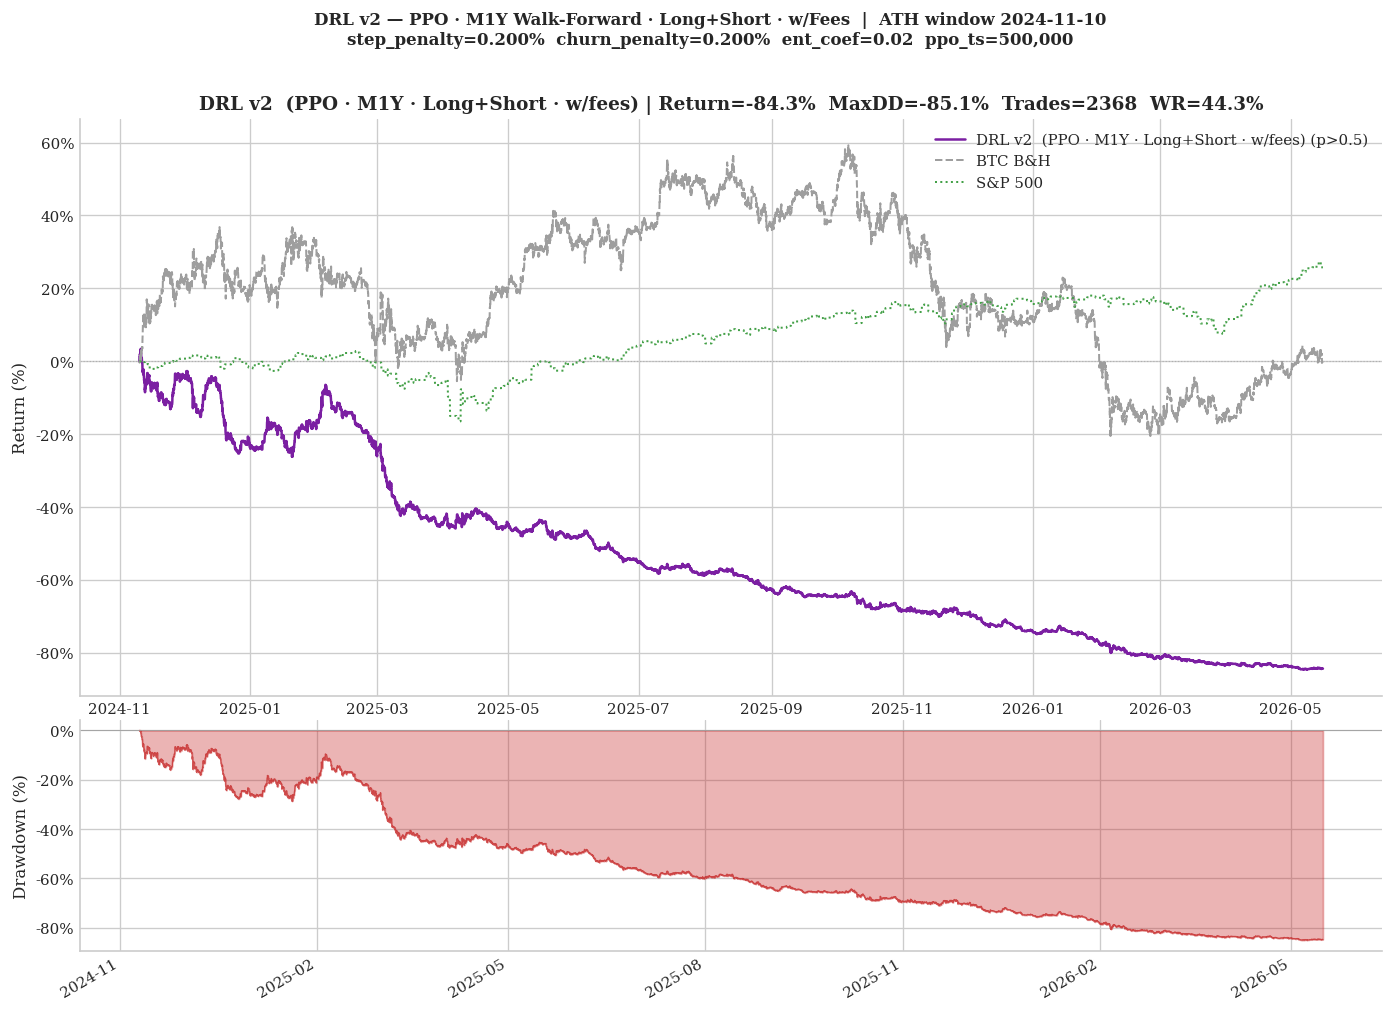

In [7]:
# ── PHASE 3: Equity / drawdown plot ──────────────────────────────────────────
fig = plot_equity_drawdown(
    oos_index_ath, eq_fees_ath, tdf_fees,
    bh_pct=bh_pct, sp500_pct=sp500_pct,
    label='DRL v2  (PPO \u00b7 M1Y \u00b7 Long+Short \u00b7 w/fees)',
    threshold=0.5, color=PURPLE,
)
fig.suptitle(
    f'DRL v2 \u2014 PPO \u00b7 M1Y Walk-Forward \u00b7 Long+Short \u00b7 w/Fees  |  ATH window {ATH_START.date()}\n'
    f'step_penalty={STEP_PENALTY:.3%}  churn_penalty={CHURN_PENALTY:.3%}  '
    f'ent_coef={ENT_COEF}  ppo_ts={TOTAL_TIMESTEPS:,}',
    fontsize=10, fontweight='bold',
)
save_fig(fig, ARTS_DIR / '01_equity_drawdown.png')
plt.show()

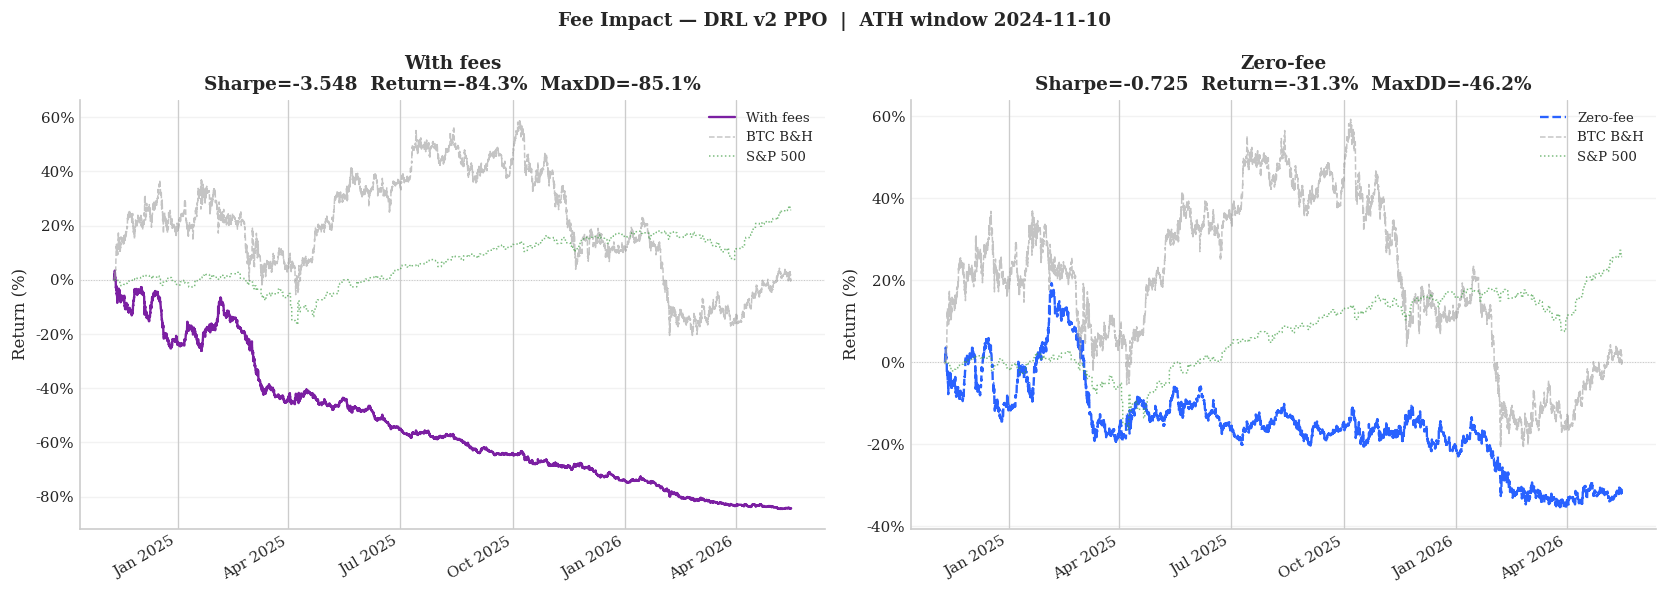

In [8]:
# ── Fee comparison plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (lbl, eq, color, ls) in zip(axes, [
    ('With fees', eq_fees_ath, PURPLE, '-'),
    ('Zero-fee',  eq_0fee_ath, BLUE,   '--'),
]):
    ax.plot(oos_index_ath, (eq-1)*100, color=color, lw=1.4, ls=ls, label=lbl)
    ax.plot(oos_index_ath, bh_pct, color=GREY, lw=0.9, ls='--', alpha=0.6, label='BTC B&H')
    if sp500_pct is not None:
        ax.plot(oos_index_ath, sp500_pct.values, color='#43A047', lw=0.9, ls=':', alpha=0.7, label='S&P 500')
    ax.axhline(0, color=GREY, lw=0.6, ls=':', alpha=0.5)
    sh=_sharpe(eq); ret=eq[-1]-1; dd=_maxdd(eq)
    ax.set_title(f'{lbl}\nSharpe={sh:.3f}  Return={ret:+.1%}  MaxDD={dd:.1%}', fontweight='bold')
    ax.set_ylabel('Return (%)'); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}%'))
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.25)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle(f'Fee Impact \u2014 DRL v2 PPO  |  ATH window {ATH_START.date()}', fontweight='bold', fontsize=11)
fig.tight_layout()
save_fig(fig, ARTS_DIR / '02_fee_comparison.png')
plt.show()

Monthly stats (w/ fees, full OOS):
  Positive months : 3 / 29
  Avg monthly ret : -8.38%
  Median monthly  : -9.19%
  Best month      : +10.24%  (Jan 2025)
  Worst month     : -25.13%  (Mar 2025)


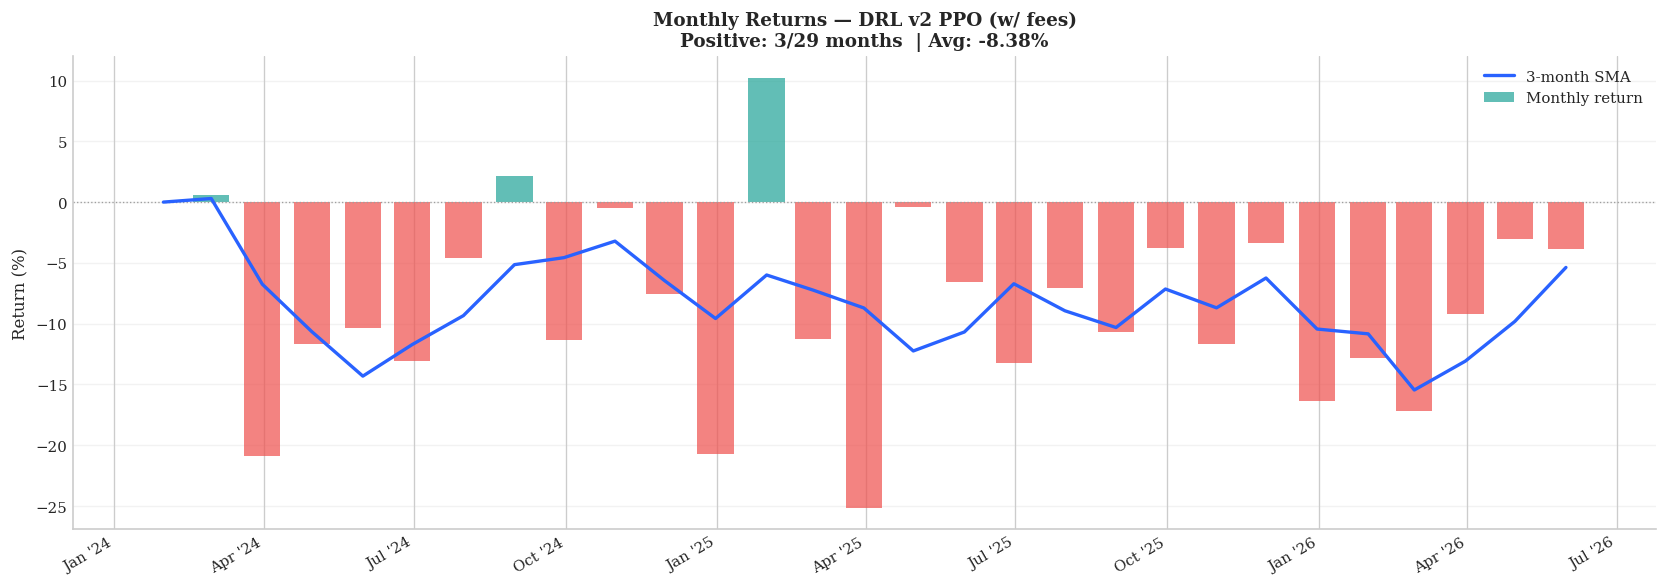

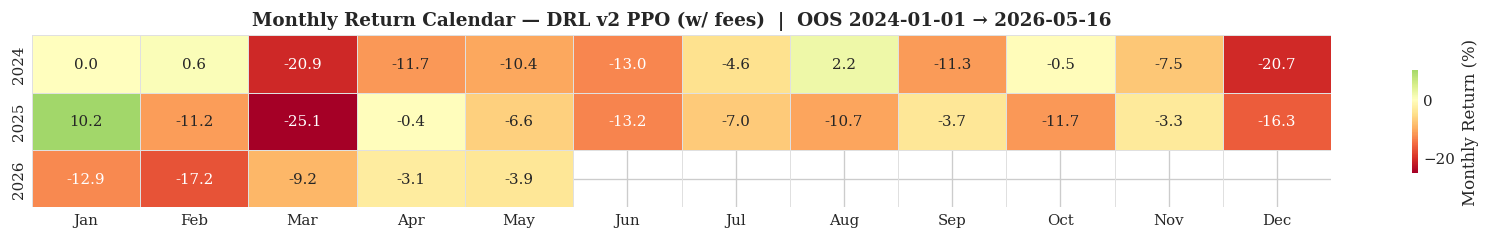

In [9]:
# ── Monthly return analysis ───────────────────────────────────────────────────
eq_full_series = pd.Series(eq_fees, index=oos_df.index)
monthly_eq  = eq_full_series.resample('ME').last()
monthly_ret = monthly_eq.pct_change().fillna(0) * 100
sma3 = monthly_ret.rolling(3, min_periods=1).mean()

print('Monthly stats (w/ fees, full OOS):')
print(f'  Positive months : {(monthly_ret>0).sum()} / {len(monthly_ret)}')
print(f'  Avg monthly ret : {monthly_ret.mean():+.2f}%')
print(f'  Median monthly  : {monthly_ret.median():+.2f}%')
print(f'  Best month      : {monthly_ret.max():+.2f}%  ({monthly_ret.idxmax().strftime("%b %Y")})')
print(f'  Worst month     : {monthly_ret.min():+.2f}%  ({monthly_ret.idxmin().strftime("%b %Y")})')

fig, ax = plt.subplots(figsize=(14, 5))
colors = [GREEN if r >= 0 else RED for r in monthly_ret.values]
ax.bar(monthly_ret.index, monthly_ret.values, color=colors, alpha=0.72, width=22, label='Monthly return')
ax.plot(monthly_ret.index, sma3.values, color=BLUE, lw=2.0, label='3-month SMA', zorder=5)
ax.axhline(0, color=GREY, lw=0.8, ls=':')
ax.set_ylabel('Return (%)')
ax.set_title(f'Monthly Returns \u2014 DRL v2 PPO (w/ fees)\n'
             f'Positive: {(monthly_ret>0).sum()}/{len(monthly_ret)} months  '
             f'| Avg: {monthly_ret.mean():+.2f}%', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.25)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
fig.tight_layout()
save_fig(fig, ARTS_DIR / '03_monthly_returns.png')
plt.show()

# Calendar heatmap
cal_df = monthly_ret.to_frame('ret').copy()
cal_df['year'] = cal_df.index.year; cal_df['month'] = cal_df.index.month
pivot = cal_df.pivot(index='year', columns='month', values='ret')
pivot.columns = [calendar.month_abbr[m] for m in pivot.columns]
fig2, ax2 = plt.subplots(figsize=(14, max(2, len(pivot)*0.7)))
sns.heatmap(pivot, ax=ax2, cmap='RdYlGn', center=0, annot=True, fmt='.1f',
            linewidths=0.5, linecolor='#e0e0e0', cbar_kws={'label': 'Monthly Return (%)', 'shrink': 0.6},
            annot_kws={'size': 9})
ax2.set_title(f'Monthly Return Calendar \u2014 DRL v2 PPO (w/ fees)  |  OOS {OOS_START.date()} \u2192 {oos_df.index[-1].date()}',
              fontweight='bold')
ax2.set_xlabel(''); ax2.set_ylabel('')
fig2.tight_layout()
save_fig(fig2, ARTS_DIR / '04_monthly_heatmap.png')
plt.show()

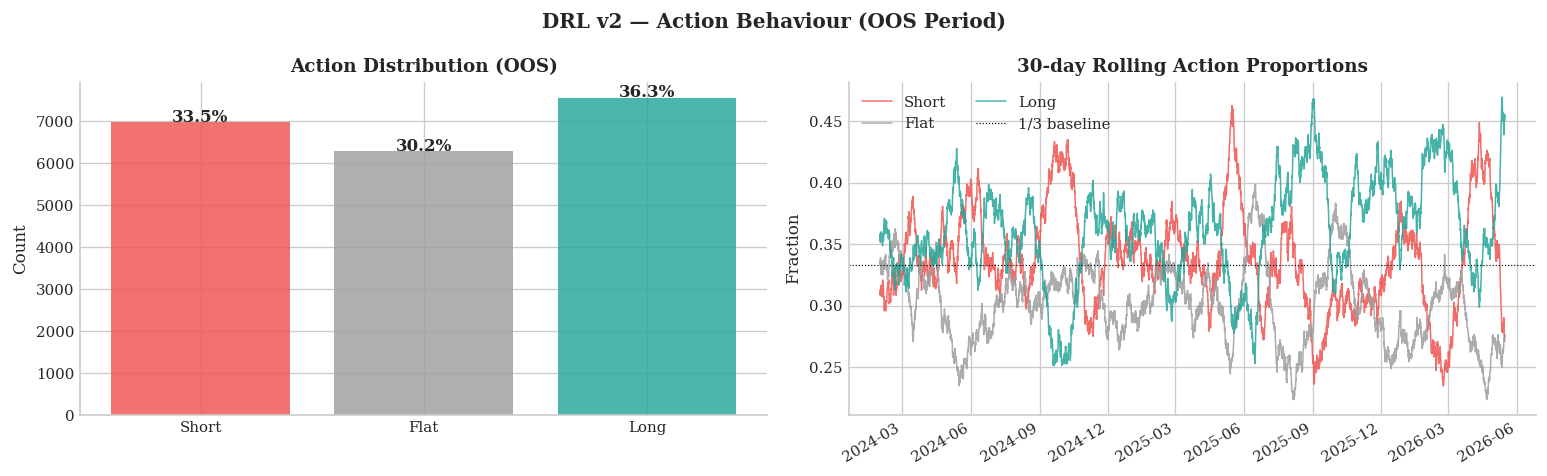

In [10]:
# ── Action distribution over OOS period ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
action_counts = pd.Series(_acts).value_counts().sort_index()
ac_labels = {-1: 'Short', 0: 'Flat', 1: 'Long'}
ac_colors = {-1: RED, 0: GREY, 1: GREEN}
bars = ax.bar([ac_labels[k] for k in action_counts.index],
              action_counts.values,
              color=[ac_colors[k] for k in action_counts.index], alpha=0.82)
for bar, v in zip(bars, action_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{v/len(_acts)*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Action Distribution (OOS)', fontweight='bold')
ax.set_ylabel('Count')

ax = axes[1]
act_series = pd.Series(_acts, index=drl_signals.index)
roll_w = 720
for act_val, col, name in [(-1, RED, 'Short'), (0, GREY, 'Flat'), (1, GREEN, 'Long')]:
    frac = (act_series == act_val).rolling(roll_w).mean()
    ax.plot(frac.index, frac, color=col, lw=0.9, alpha=0.85, label=name)
ax.axhline(1/3, color='black', ls=':', lw=0.7, label='1/3 baseline')
ax.set_title('30-day Rolling Action Proportions', fontweight='bold')
ax.set_ylabel('Fraction'); ax.legend(ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle('DRL v2 \u2014 Action Behaviour (OOS Period)', fontweight='bold')
fig.tight_layout()
save_fig(fig, ARTS_DIR / '05_action_distribution.png')
plt.show()

In [11]:
# ── v1 vs v2 comparison ───────────────────────────────────────────────────────
v1_sig_path     = REPO_DIR / 'artifacts' / '07_drl_omni_0fee_v1' / 'drl_oos_signals.parquet'
v1_results_path = REPO_DIR / 'artifacts' / '07_drl_omni_0fee_v1' / 'results.json'

if v1_sig_path.exists() and v1_results_path.exists():
    v1_sigs = pd.read_parquet(v1_sig_path)['drl_action'].reindex(drl_signals.index).fillna(0).astype(int)
    with open(v1_results_path) as f:
        v1_res = json.load(f)
    v1m = v1_res['backtest_wfees']
    v1_flat_pct = v1_res['action_dist'].get('0', 0) / sum(v1_res['action_dist'].values()) * 100

    v2_flat_pct = (drl_signals == 0).mean() * 100
    v2_wr = (tdf_fees['net'] > 0).mean() if len(tdf_fees) else 0.

    print('\n\u250c' + '\u2500'*63 + '\u2510')
    print(f'\u2502  {"METRIC":<28} {"DRL v1":>14} {"DRL v2":>14}  \u2502')
    print('\u251c' + '\u2500'*63 + '\u2524')
    print(f'\u2502  {"Trades (OOS)":<28} {v1m["n_trades"]:>14,} {len(tdf_fees):>14,}  \u2502')
    print(f'\u2502  {"Flat % (OOS)":<28} {v1_flat_pct:>13.1f}% {v2_flat_pct:>13.1f}%  \u2502')
    print(f'\u2502  {"Win Rate (w/fees)":<28} {v1m["win_rate"]:>13.1%} {v2_wr:>13.1%}  \u2502')
    print(f'\u2502  {"Return (w/fees)":<28} {v1m["total_ret"]:>13.1%} {eq_fees[-1]-1:>13.1%}  \u2502')
    print(f'\u2502  {"Sharpe (w/fees)":<28} {v1m["sharpe"]:>14.3f} {_sharpe(eq_fees):>14.3f}  \u2502')
    print(f'\u2502  {"Max Drawdown":<28} {v1m["maxdd"]:>13.1%} {_maxdd(eq_fees):>13.1%}  \u2502')
    v1_0fee = v1_res['backtest_0fee']
    print('\u251c' + '\u2500'*63 + '\u2524')
    print(f'\u2502  {"Return (0-fee)":<28} {v1_0fee["total_ret"]:>13.1%} {eq_0fee[-1]-1:>13.1%}  \u2502')
    print(f'\u2502  {"Sharpe (0-fee)":<28} {v1_0fee["sharpe"]:>14.3f} {_sharpe(eq_0fee):>14.3f}  \u2502')
    print('\u2514' + '\u2500'*63 + '\u2518')
else:
    print('v1 artifacts not found \u2014 run 07_drl_omni_0fee_v1 first for comparison.')
    print(f'\nv2 summary  (full OOS, w/ fees):')
    print(f'  Trades  : {len(tdf_fees):,}')
    print(f'  Flat %  : {(drl_signals==0).mean():.1%}')
    print(f'  Return  : {eq_fees[-1]-1:+.2%}')
    print(f'  Sharpe  : {_sharpe(eq_fees):.3f}')
    print(f'  Max DD  : {_maxdd(eq_fees):.2%}')


┌───────────────────────────────────────────────────────────────┐
│  METRIC                               DRL v1         DRL v2  │
├───────────────────────────────────────────────────────────────┤
│  Trades (OOS)                          2,483          2,368  │
│  Flat % (OOS)                          33.0%          30.2%  │
│  Win Rate (w/fees)                    44.0%         44.3%  │
│  Return (w/fees)                     -86.0%        -92.5%  │
│  Sharpe (w/fees)                      -2.292         -3.050  │
│  Max Drawdown                        -87.2%        -93.3%  │
├───────────────────────────────────────────────────────────────┤
│  Return (0-fee)                       63.9%        -21.6%  │
│  Sharpe (0-fee)                        0.578         -0.288  │
└───────────────────────────────────────────────────────────────┘


In [12]:
# ── Save results.json ─────────────────────────────────────────────────────────
def _bt_metrics(eq, tdf, label):
    wr  = float((tdf['net']>0).mean()) if len(tdf) else 0.
    n_l = int((tdf['direction']=='long').sum())  if len(tdf) else 0
    n_s = int((tdf['direction']=='short').sum()) if len(tdf) else 0
    return {'label': label, 'n_trades': len(tdf), 'n_long': n_l, 'n_short': n_s,
            'win_rate': round(wr, 4),
            'total_ret': round(float(eq[-1]-1), 4),
            'sharpe': round(_sharpe(eq), 4),
            'maxdd': round(_maxdd(eq), 4),
            'ath_total_ret': round(float(_rebase(eq)[-1]-1), 4),
            'ath_sharpe': round(_sharpe(_rebase(eq)), 4),
            'ath_maxdd': round(_maxdd(_rebase(eq)), 4)}

results = {
    'notebook': '07_drl_omni_0fee_v2',
    'version': 'v2',
    'created': pd.Timestamp.now().isoformat(),
    'algorithm': 'PPO (Stable-Baselines3)',
    'scheme': 'M1Y (1-year sliding)',
    'direction': 'long+short',
    'v2_fixes': {
        'step_penalty': STEP_PENALTY,
        'churn_penalty': CHURN_PENALTY,
        'ent_coef': ENT_COEF,
        'total_timesteps': TOTAL_TIMESTEPS,
        'episode_len': EPISODE_LEN,
        'randomised_reset': True,
    },
    'oos_period': f'{OOS_START.date()} \u2192 {oos_df.index[-1].date()}',
    'ath_window': f'{ATH_START.date()} \u2192 {oos_ath.index[-1].date()}',
    'n_features': len(agent.features),
    'window_size': 24,
    'total_timesteps_per_fold': TOTAL_TIMESTEPS,
    'fees': {'taker': TAKER_FEE, 'funding_h': FUNDING_H},
    'action_dist': {str(k): int(v) for k, v in pd.Series(_acts).value_counts().sort_index().items()},
    'backtest_wfees': _bt_metrics(eq_fees, tdf_fees, 'w_fees'),
    'backtest_0fee':  _bt_metrics(eq_0fee, tdf_0fee, '0_fee'),
    'monthly_returns': {
        'mean_pct': round(float(monthly_ret.mean()), 3),
        'median_pct': round(float(monthly_ret.median()), 3),
        'std_pct': round(float(monthly_ret.std()), 3),
        'positive_months': int((monthly_ret > 0).sum()),
        'total_months': int(len(monthly_ret)),
    }
}

out_path = ARTS_DIR / 'results.json'
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'Saved \u2192 {out_path}')
print(json.dumps(results, indent=2)[:1500])

Saved → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/07_drl_omni_0fee_v2/results.json
{
  "notebook": "07_drl_omni_0fee_v2",
  "version": "v2",
  "created": "2026-06-02T22:39:23.176620",
  "algorithm": "PPO (Stable-Baselines3)",
  "scheme": "M1Y (1-year sliding)",
  "direction": "long+short",
  "v2_fixes": {
    "step_penalty": 0.002,
    "churn_penalty": 0.002,
    "ent_coef": 0.02,
    "total_timesteps": 500000,
    "episode_len": 1000,
    "randomised_reset": true
  },
  "oos_period": "2024-01-01 \u2192 2026-05-16",
  "ath_window": "2024-11-10 \u2192 2026-05-16",
  "n_features": 19,
  "window_size": 24,
  "total_timesteps_per_fold": 500000,
  "fees": {
    "taker": 0.0005,
    "funding_h": 7.7e-06
  },
  "action_dist": {
    "-1": 6962,
    "0": 6276,
    "1": 7547
  },
  "backtest_wfees": {
    "label": "w_fees",
    "n_trades": 2368,
    "n_long": 1209,
    "n_short": 1159,
    "win_rate": 0.443,
    "total_ret": -0.9252,
    "sharpe": -3.0503,
    